# Repository Static Analysis with SonarQube

Clones a **GitHub repository**, scans it with a local SonarQube Community server, and reports
**code complexity** (cyclomatic + cognitive, per project and per file) and **issues**
(bugs, vulnerabilities, code smells).

Runs on Windows, macOS and Linux — the scanner binary is chosen automatically for your platform.

## Prerequisites
- **Docker Desktop** installed and *running* (this notebook starts the SonarQube container for you)
- **git** on your PATH
- **Java 17+** on your PATH (`java -version`)
- ~4 GB free RAM for the SonarQube container

Run the cells top to bottom. The first run takes a few minutes (image pull + server boot).

## 0. Dependencies

In [14]:
%pip install -q requests pandas matplotlib lizard


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Configuration

Point `REPO_URL` at the GitHub repo you want to analyze. Everything else has a sane default.

In [ ]:
import os, re, sys, platform, pathlib

# ---- what to analyze -------------------------------------------------------
REPO_URL    = "https://github.com/ImgyeongLee/Aida-starter-template.git"
REPO_BRANCH = "r2-0901"     # None = the repo's default branch
REPO_BRANCHES = ["main","r1-0901", "r2-0901", "r3-0901", "r4-0901"]  # for multi-branch analysis
CLONE_DEPTH = 1             # shallow clone; set to None for full history

# SonarQube Community Edition has NO branch support - every scan of a given
# project key overwrites the previous one. Keep this True to give each branch
# its own project, so branches can be compared side by side.
SEPARATE_PROJECT_PER_BRANCH = True

# ---- where things live -----------------------------------------------------
WORKSPACE    = pathlib.Path.cwd()
PROJECTS_DIR = WORKSPACE / "projects"
TOOLS_DIR    = WORKSPACE / ".tools"
TOKEN_FILE   = WORKSPACE / ".sonar-token"      # generated token is cached here

# ---- SonarQube server ------------------------------------------------------
SONAR_HOST      = "http://localhost:9000"
SONAR_IMAGE     = "sonarqube:community"
SONAR_CONTAINER = "sonarqube"
SONAR_ADMIN     = "admin"
SONAR_DEFAULT_PASSWORD = "admin"               # factory default
SONAR_NEW_PASSWORD     = "admin"       # set on first boot (Sonar forces a change)

# ---- scanner ---------------------------------------------------------------
SCANNER_VERSION = "7.2.0.5079"
SCANNER_OPTS    = "-Xmx2048m"                  # raise if the scan OOMs on a big repo
if platform.system() == "Darwin":
    # works around a JDK/macOS posix_spawn bug where the scanner crashes trying to
    # read the system keychain (java.io.IOException: Cannot run program "security":
    # error=0, posix_spawn failed) - forcing the classic fork() path avoids it.
    SCANNER_OPTS += " -Djdk.lang.Process.launchMechanism=FORK"

# ---- what to skip ----------------------------------------------------------
# Repo-specific directories to leave out of the analysis, relative to the repo
# root. Add or remove entries here, then re-run from this cell.
EXCLUDE_DIRS = [
    "apps/extension",
]

# Generic build output / vendored code that should never be analyzed.
_BOILERPLATE_EXCLUSIONS = [
    "**/node_modules/**", "**/dist/**", "**/build/**", "**/out/**", "**/target/**",
    "**/vendor/**", "**/.venv/**", "**/venv/**", "**/__pycache__/**",
    "**/*.min.js", "**/*.min.css", "**/*.lock", "**/*-lock.json", "**/*.map",
]

EXCLUSIONS = ",".join(
    _BOILERPLATE_EXCLUSIONS + [f"{d.strip('/')}/**" for d in EXCLUDE_DIRS]
)

# ---- derived ---------------------------------------------------------------
REPO_NAME = re.sub(r"\.git$", "", REPO_URL.rstrip("/").split("/")[-1])
REPO_DIR  = PROJECTS_DIR / REPO_NAME

_key_base = REPO_NAME
if SEPARATE_PROJECT_PER_BRANCH and REPO_BRANCH:
    _key_base = f"{REPO_NAME}--{REPO_BRANCH}"

PROJECT_KEY  = re.sub(r"[^A-Za-z0-9_.\-]", "-", _key_base)
PROJECT_NAME = _key_base

PROJECTS_DIR.mkdir(exist_ok=True)
TOOLS_DIR.mkdir(exist_ok=True)

print(f"Repository : {REPO_URL}")
print(f"Branch     : {REPO_BRANCH or '(default)'}")
print(f"Clone path : {REPO_DIR}")
print(f"Project key: {PROJECT_KEY}")
print(f"Platform   : {platform.system()} / {platform.machine()}")
print("Excluding  :", ", ".join(EXCLUDE_DIRS) or "(nothing repo-specific)")


Repository : https://github.com/ImgyeongLee/Aida-starter-template.git
Branch     : r2-0901
Clone path : /Users/lukas./Desktop/RepositoryStaticAnalysis/projects/Aida-starter-template
Project key: Aida-starter-template--r2-0901
Platform   : Darwin / arm64
Excluding  : apps/extension


## 2. Sanity-check the toolchain

Fails loudly here rather than three cells later.

In [16]:
import shutil, subprocess

def _run(cmd, **kw):
    return subprocess.run(cmd, capture_output=True, text=True,
                          encoding="utf-8", errors="replace", **kw)

ok = True

for tool, probe in [("git", ["git", "--version"]),
                    ("java", ["java", "-version"]),
                    ("docker", ["docker", "--version"])]:
    if shutil.which(tool) is None:
        print(f"MISSING: {tool} is not on your PATH")
        ok = False
        continue
    r = _run(probe)
    print(f"OK  {tool:7s} {(r.stdout or r.stderr).splitlines()[0]}")

# the docker CLI existing does not mean the daemon is running
r = _run(["docker", "info", "--format", "{{.ServerVersion}}"])
if r.returncode != 0:
    print("\nDocker daemon is NOT running. Start Docker Desktop, wait for it, re-run this cell.")
    ok = False
else:
    print(f"OK  daemon  Docker engine {r.stdout.strip()}")

print("\nAll prerequisites satisfied." if ok else "\nFix the items above before continuing.")

OK  git     git version 2.42.0
OK  java    openjdk version "19.0.2" 2023-01-17
OK  docker  Docker version 29.4.0, build 9d7ad9f
OK  daemon  Docker engine 29.4.0

All prerequisites satisfied.


## 3. Clone (or refresh) the repository

In [17]:
from collections import Counter

def git(*args):
    return _run(["git", "-C", str(REPO_DIR)] + list(args))

if not REPO_DIR.exists():
    cmd = ["git", "clone"]
    if CLONE_DEPTH:
        cmd += ["--depth", str(CLONE_DEPTH)]
    if REPO_BRANCH:
        cmd += ["--branch", REPO_BRANCH]
    cmd += [REPO_URL, str(REPO_DIR)]
    print("Cloning ...")
    r = _run(cmd)
    if r.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{r.stderr}")
    print(f"Cloned into {REPO_DIR}")
else:
    print(f"Already cloned: {REPO_DIR}")

# --- make the working tree actually match REPO_BRANCH -----------------------
# A --depth clone is single-branch, so widen the refspec before fetching or
# other branches will never be visible.
git("config", "remote.origin.fetch", "+refs/heads/*:refs/remotes/origin/*")

if REPO_BRANCH:
    r = git("fetch", "origin", REPO_BRANCH, "--quiet")
    if r.returncode != 0:
        raise RuntimeError(f"Could not fetch branch '{REPO_BRANCH}':\n{r.stderr}")

    # never clobber uncommitted work (.scannerwork is untracked, so it is ignored here)
    dirty = git("status", "--porcelain", "--untracked-files=no").stdout.strip()
    if dirty:
        raise RuntimeError(
            f"{REPO_DIR} has uncommitted changes - refusing to switch branches.\n"
            f"{dirty}\nCommit or discard them, then re-run this cell."
        )

    r = git("checkout", "-B", REPO_BRANCH, f"origin/{REPO_BRANCH}", "--quiet")
    if r.returncode != 0:
        raise RuntimeError(f"Could not check out '{REPO_BRANCH}':\n{r.stderr}")
else:
    git("fetch", "--all", "--quiet")

current = git("rev-parse", "--abbrev-ref", "HEAD").stdout.strip()
head    = git("log", "-1", "--format=%h %ad %s", "--date=short").stdout.strip()

# fail loudly rather than silently scanning the wrong code
if REPO_BRANCH and current != REPO_BRANCH:
    raise RuntimeError(f"Expected branch '{REPO_BRANCH}' but the tree is on '{current}'")

print(f"Branch : {current}")
print(f"HEAD   : {head}")

# quick language census, so you know what Sonar will actually see
counts = Counter()
for p in REPO_DIR.rglob("*"):
    parts = p.parts
    if p.is_file() and ".git" not in parts and "node_modules" not in parts and p.suffix:
        counts[p.suffix] += 1
print("\nTop file extensions:")
for ext, n in counts.most_common(10):
    print(f"  {ext:8s} {n}")


Already cloned: /Users/lukas./Desktop/RepositoryStaticAnalysis/projects/Aida-starter-template
Branch : r2-0901
HEAD   : c8858ff 2026-09-01 completed: round 2 (Sep 1st)

Top file extensions:
  .ts      48
  .json    18
  .tsx     16
  .js      4
  .svg     4
  .yaml    2
  .md      2
  .sh      2
  .example 2
  .txt     1


## 4. Start the SonarQube server

Starts the container if it is not already up, then waits for the server to report `UP`.
A cold start pulls the image and takes 1-3 minutes.

In [18]:
%pip install -q requests
import time, requests

def container_state(name):
    r = _run(["docker", "inspect", "-f", "{{.State.Status}}", name])
    return r.stdout.strip() if r.returncode == 0 else None

state = container_state(SONAR_CONTAINER)
if state is None:
    print(f"Creating container '{SONAR_CONTAINER}' from {SONAR_IMAGE} (may pull the image) ...")
    r = _run(["docker", "run", "-d", "--name", SONAR_CONTAINER, "-p", "9000:9000", SONAR_IMAGE])
    if r.returncode != 0:
        raise RuntimeError(f"docker run failed:\n{r.stderr}")
    print("Container created.")
elif state != "running":
    print(f"Container exists but is '{state}' - starting it ...")
    _run(["docker", "start", SONAR_CONTAINER])
else:
    print("Container already running.")

print("\nWaiting for SonarQube to come up (this is the slow part) ...")
deadline = time.time() + 420
status = None
while time.time() < deadline:
    try:
        status = requests.get(f"{SONAR_HOST}/api/system/status", timeout=5).json().get("status")
    except requests.RequestException:
        status = "STARTING (no response yet)"
    if status == "UP":
        break
    print(f"  ... {status}")
    time.sleep(10)

if status != "UP":
    print(f"\nServer did not reach UP within the timeout (last status: {status}).")
    print(f"Check the logs:  docker logs --tail 50 {SONAR_CONTAINER}")
else:
    v = requests.get(f"{SONAR_HOST}/api/server/version", timeout=10).text.strip()
    print(f"\nSonarQube is UP - version {v}")


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Container already running.

Waiting for SonarQube to come up (this is the slow part) ...

SonarQube is UP - version 26.5.0.122743


## 5. Authenticate

SonarQube forces a password change away from the `admin/admin` default on first boot.
This cell handles that, then mints an analysis token and caches it in `.sonar-token`
so re-runs do not need to regenerate it.

In [19]:
TOKEN_NAME = "notebook-token"

def _api(method, path, auth, **kw):
    return requests.request(method, f"{SONAR_HOST}{path}", auth=auth, timeout=30, **kw)

# 1. find the working admin password: the rotated one if already set, else the factory default
admin_auth = None
for candidate in (SONAR_NEW_PASSWORD, SONAR_DEFAULT_PASSWORD):
    try:
        valid = _api("GET", "/api/authentication/validate",
                     (SONAR_ADMIN, candidate)).json().get("valid")
    except Exception:
        valid = False
    if valid:
        admin_auth = (SONAR_ADMIN, candidate)
        print(f"Authenticated as '{SONAR_ADMIN}'.")
        break

if admin_auth is None:
    raise RuntimeError(
        "Could not log in as admin with either the default or the configured password.\n"
        "If you changed it manually, set SONAR_NEW_PASSWORD in the config cell."
    )

# 2. rotate off the factory default if we are still on it
if admin_auth[1] == SONAR_DEFAULT_PASSWORD and SONAR_NEW_PASSWORD != SONAR_DEFAULT_PASSWORD:
    r = _api("POST", "/api/users/change_password", admin_auth,
             data={"login": SONAR_ADMIN,
                   "previousPassword": SONAR_DEFAULT_PASSWORD,
                   "password": SONAR_NEW_PASSWORD})
    if r.status_code in (200, 204):
        admin_auth = (SONAR_ADMIN, SONAR_NEW_PASSWORD)
        print("Rotated the default admin password.")
    else:
        print(f"Password change returned {r.status_code} - continuing with the current one.")

# 3. reuse a cached token, or mint a fresh one
SONAR_TOKEN = TOKEN_FILE.read_text().strip() if TOKEN_FILE.exists() else ""

token_ok = False
if SONAR_TOKEN:
    token_ok = _api("GET", "/api/authentication/validate",
                    (SONAR_TOKEN, "")).json().get("valid", False)

if token_ok:
    print(f"Reusing cached token from {TOKEN_FILE.name}")
else:
    _api("POST", "/api/user_tokens/revoke", admin_auth, data={"name": TOKEN_NAME})  # no-op if absent
    r = _api("POST", "/api/user_tokens/generate", admin_auth, data={"name": TOKEN_NAME})
    if r.status_code != 200:
        raise RuntimeError(f"Token generation failed ({r.status_code}): {r.text}")
    SONAR_TOKEN = r.json()["token"]
    TOKEN_FILE.write_text(SONAR_TOKEN)
    print(f"Generated a new analysis token, cached in {TOKEN_FILE.name}")

auth = (SONAR_TOKEN, "")   # token auth for every call from here on

Authenticated as 'admin'.
Reusing cached token from .sonar-token


## 6. Download the sonar-scanner CLI for this platform

In [20]:
import zipfile, stat

def scanner_platform():
    sysname, machine = platform.system(), platform.machine().lower()
    arm = machine in ("arm64", "aarch64")
    if sysname == "Windows":
        return "windows-x64", "sonar-scanner.bat"
    if sysname == "Darwin":
        return ("macosx-aarch64" if arm else "macosx-x64"), "sonar-scanner"
    if sysname == "Linux":
        return ("linux-aarch64" if arm else "linux-x64"), "sonar-scanner"
    raise RuntimeError(f"Unsupported platform: {sysname}/{machine}")

plat, binary_name = scanner_platform()
dist = f"sonar-scanner-{SCANNER_VERSION}-{plat}"
scanner_home = TOOLS_DIR / dist
SCANNER_BIN = scanner_home / "bin" / binary_name

if SCANNER_BIN.exists():
    print(f"Scanner already installed: {SCANNER_BIN}")
else:
    url = ("https://binaries.sonarsource.com/Distribution/sonar-scanner-cli/"
           f"sonar-scanner-cli-{SCANNER_VERSION}-{plat}.zip")
    zip_path = TOOLS_DIR / "scanner.zip"
    print(f"Downloading {url} ...")
    # requests (via certifi) ships its own CA bundle, unlike urllib.request which
    # relies on the system trust store - on macOS python.org builds that store
    # is often not wired up, which fails as SSLCertVerificationError.
    with requests.get(url, stream=True, timeout=60) as resp:
        resp.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(TOOLS_DIR)
    zip_path.unlink()
    # the zip does not carry the exec bit on POSIX
    if platform.system() != "Windows":
        for f in (scanner_home / "bin").iterdir():
            f.chmod(f.stat().st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
        jre = scanner_home / "jre" / "bin" / "java"
        if jre.exists():
            jre.chmod(jre.stat().st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
    print(f"Installed: {SCANNER_BIN}")

if not SCANNER_BIN.exists():
    raise RuntimeError(f"Scanner binary not found at {SCANNER_BIN}")


Scanner already installed: /Users/lukas./Desktop/RepositoryStaticAnalysis/.tools/sonar-scanner-7.2.0.5079-macosx-aarch64/bin/sonar-scanner


## 7. Create the project on the server

In [21]:
r = _api("POST", "/api/projects/create", auth,
         data={"project": PROJECT_KEY, "name": PROJECT_NAME})

if r.status_code in (200, 204):
    print(f"Created project '{PROJECT_KEY}'.")
elif r.status_code == 400:
    msg = r.json().get("errors", [{}])[0].get("msg", "")
    print(f"Project '{PROJECT_KEY}' already exists - reusing it.  ({msg})")
else:
    raise RuntimeError(f"Unexpected response {r.status_code}: {r.text}")

Project 'Aida-starter-template--r2-0901' already exists - reusing it.  (Could not create Project with key: "Aida-starter-template--r2-0901". A similar key already exists: "Aida-starter-template--r2-0901")


## 8. Run the scan

Streams the scanner output, then **polls the server's background task** until the report is
actually ingested. (Sleeping a few seconds and hoping is the classic cause of
"my results are empty, or from the previous run".)

In [22]:
VERBOSE_SCAN = False   # True to see every INFO line

scan_env = dict(os.environ, SONAR_SCANNER_OPTS=SCANNER_OPTS)

cmd = [
    str(SCANNER_BIN),
    f"-Dsonar.projectKey={PROJECT_KEY}",
    f"-Dsonar.projectName={PROJECT_NAME}",
    "-Dsonar.sources=.",
    f"-Dsonar.projectBaseDir={REPO_DIR}",
    f"-Dsonar.host.url={SONAR_HOST}",
    f"-Dsonar.token={SONAR_TOKEN}",
    f"-Dsonar.exclusions={EXCLUSIONS}",
    "-Dsonar.sourceEncoding=UTF-8",
    "-Dsonar.scm.disabled=true",
]

print(f"Scanning {REPO_DIR} ...\n")
proc = subprocess.Popen(cmd, cwd=str(REPO_DIR), env=scan_env,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, encoding="utf-8", errors="replace", bufsize=1)

KEEP = ("WARN", "ERROR", "EXECUTION", "ANALYSIS SUCCESSFUL", "indexed", "Load", "QUALITY")
tail = []
for line in proc.stdout:
    line = line.rstrip()
    tail.append(line)
    tail = tail[-60:]
    if VERBOSE_SCAN or any(k in line for k in KEEP):
        print(line)

rc = proc.wait()
if rc != 0:
    print("\n--- last 60 lines ---")
    print("\n".join(tail))
    raise RuntimeError(f"sonar-scanner exited with code {rc}")

print(f"\nScanner finished (exit {rc}).")

Scanning /Users/lukas./Desktop/RepositoryStaticAnalysis/projects/Aida-starter-template ...

12:37:09.510 INFO  Load global settings
12:37:09.626 INFO  Load global settings (done) | time=118ms
12:37:09.633 INFO  Loading required plugins
12:37:09.633 INFO  Load plugins index
12:37:09.651 INFO  Load plugins index (done) | time=17ms
12:37:09.651 INFO  Load/download plugins
12:37:09.680 INFO  Load/download plugins (done) | time=30ms
12:37:09.931 INFO  Load project settings for component key: 'Aida-starter-template--r2-0901'
12:37:09.969 INFO  Load project settings for component key: 'Aida-starter-template--r2-0901' (done) | time=38ms
12:37:09.990 INFO  Load quality profiles
12:37:10.129 INFO  Load quality profiles (done) | time=140ms
12:37:10.153 INFO  Load active rules
12:37:10.598 INFO  Load active rules (done) | time=444ms
12:37:10.605 INFO  Load analysis cache
12:37:10.650 INFO  Load analysis cache | time=45ms
12:37:10.941 INFO  Loading plugins for detected languages
12:37:10.941 INFO  

In [23]:
# Wait for the server to finish processing the submitted report.
task_file = REPO_DIR / ".scannerwork" / "report-task.txt"
if not task_file.exists():
    raise RuntimeError(f"{task_file} not found - the scan did not submit a report.")

meta = dict(l.split("=", 1) for l in task_file.read_text().strip().splitlines() if "=" in l)
task_id = meta["ceTaskId"]
print(f"Background task {task_id} - waiting for ingestion ...")

deadline = time.time() + 300
task_status = None
while time.time() < deadline:
    task = _api("GET", "/api/ce/task", auth, params={"id": task_id}).json().get("task", {})
    task_status = task.get("status")
    if task_status in ("SUCCESS", "FAILED", "CANCELED"):
        break
    time.sleep(3)

print(f"Task status: {task_status}")
if task_status != "SUCCESS":
    raise RuntimeError(f"Report processing did not succeed (status={task_status}). See "
                       f"{SONAR_HOST}/project/background_tasks?id={PROJECT_KEY}")
print("Analysis is live on the server.")

Background task 9d8e9ecf-53c2-4719-9b40-623ab3d8a16d - waiting for ingestion ...
Task status: SUCCESS
Analysis is live on the server.


## 9. Issues

Bugs, vulnerabilities and code smells from the latest analysis.

In [ ]:
import pandas as pd

def fetch_issues(project_key, page_size=500):
    issues, page = [], 1
    while True:
        r = _api("GET", "/api/issues/search", auth, params={
            "componentKeys": project_key, "ps": page_size, "p": page, "resolved": "false",
        })
        r.raise_for_status()
        data = r.json()
        batch = data.get("issues", [])
        issues.extend(batch)
        total = data.get("total", 0)
        # SonarQube refuses to page past 10 000 results
        if not batch or len(issues) >= total or page * page_size >= 10000:
            break
        page += 1
    return issues

raw_issues = fetch_issues(PROJECT_KEY)
print(f"Open issues: {len(raw_issues)}")

rows = []
for issue in raw_issues:
    # SonarQube 10+ reports "impacts"; older versions only "severity"/"type"
    impacts = issue.get("impacts") or []
    rows.append({
        "severity": issue.get("severity") or (impacts[0]["severity"] if impacts else None),
        "type":     issue.get("type") or (impacts[0]["softwareQuality"] if impacts else None),
        "file":     issue.get("component", "").split(":", 1)[-1],
        "line":     issue.get("textRange", {}).get("startLine"),
        "rule":     issue.get("rule"),
        "effort":   issue.get("effort"),
        "message":  issue.get("message"),
    })

issues_df = pd.DataFrame(rows)

if issues_df.empty:
    print("No open issues found.")
else:
    issues_df["line"] = pd.to_numeric(issues_df["line"], errors="coerce").astype("Int64")
    sev_order = ["BLOCKER", "CRITICAL", "HIGH", "MAJOR", "MEDIUM", "MINOR", "LOW", "INFO"]
    present = [s for s in sev_order if s in set(issues_df["severity"])]
    issues_df["severity"] = pd.Categorical(issues_df["severity"], categories=present, ordered=True)
    issues_df = issues_df.sort_values(["severity", "file", "line"]).reset_index(drop=True)

    pd.set_option("display.max_colwidth", None)  # None = show full message text, no "..."
    pd.set_option("display.max_rows", 200)
    display(issues_df)

## 10. Issue summary

In [25]:
if not issues_df.empty:
    print("=== By severity ===")
    display(issues_df.groupby("severity", observed=True).size().rename("count").reset_index())

    print("=== By type ===")
    display(issues_df.groupby("type", observed=True).size().rename("count").reset_index())

    print("=== Top 10 rules ===")
    top_rules = issues_df["rule"].value_counts().head(10).reset_index()
    top_rules.columns = ["rule", "count"]
    display(top_rules)

    print("=== Top 10 files by issue count ===")
    top_files = issues_df["file"].value_counts().head(10).reset_index()
    top_files.columns = ["file", "count"]
    display(top_files)

=== By severity ===


,severity,count
0,CRITICAL,3
1,MAJOR,13
2,MINOR,23


=== By type ===


,type,count
0,CODE_SMELL,39


=== Top 10 rules ===


,rule,count
0,typescript:S6759,11
1,typescript:S7764,10
2,typescript:S6772,9
3,typescript:S6850,3
4,typescript:S3735,2
5,typescript:S3776,1
6,typescript:S4043,1
7,typescript:S7781,1
8,typescript:S4325,1


=== Top 10 files by issue count ===


,file,count
0,apps/web/src/instrumentation.ts,5
1,apps/web/src/components/SetPasswordScreen.tsx,4
2,apps/web/src/components/EnrollStudentForm.tsx,4
3,apps/web/src/components/MarkdownMessage.tsx,4
4,apps/web/src/components/CourseRoster.tsx,2
5,apps/web/src/components/AuthScreen.tsx,2
6,apps/web/src/components/BatchEnrollForm.tsx,2
7,apps/web/src/components/ForgotPasswordScreen.tsx,2
8,apps/web/src/App.tsx,2
9,apps/web/src/components/Sidebar.tsx,2


## 11. Per-function complexity (lizard)

SonarQube has no function-level data — its component model stops at `FIL`, and the
whole Complexity domain is two project-wide integers. lizard fills that gap: it
reports CCN, NLOC, token count and parameter count for **every** function.

Uses the same `EXCLUDE_DIRS` as the scan, so both halves describe the same files.

In [26]:
import lizard, pathlib
import pandas as pd

# lizard is driven through its Python API rather than by parsing `python -m lizard`
# stdout: same library, but no regex, no subprocess, and nothing to time out.

CCN_THRESHOLD = 10        # functions above this are the ones worth looking at

# lizard picks a reader per extension (.ts -> TypeScriptReader, .tsx -> TSXReader).
LIZARD_EXTENSIONS = {
    ".ts", ".tsx", ".js", ".jsx", ".py", ".java", ".go", ".rb", ".cs",
    ".c", ".cc", ".cpp", ".h", ".hpp", ".rs", ".kt", ".php", ".swift", ".scala",
}

_SKIP_DIRS = {"node_modules", "dist", "build", "out", "target", "vendor",
              ".git", ".venv", "venv", "__pycache__", ".scannerwork"}

def _excluded(rel_posix):
    """Mirror the SonarQube exclusions so both tools cover the same files."""
    if any(part in _SKIP_DIRS for part in rel_posix.split("/")):
        return True
    return any(rel_posix.startswith(d.strip("/") + "/") for d in EXCLUDE_DIRS)

def analyze_functions(root):
    root = pathlib.Path(root)
    rows, failed = [], []
    for p in sorted(root.rglob("*")):
        if not p.is_file() or p.suffix.lower() not in LIZARD_EXTENSIONS:
            continue
        rel = p.relative_to(root).as_posix()
        if _excluded(rel):
            continue
        try:
            info = lizard.analyze_file(str(p))
        except Exception as exc:
            failed.append(f"{rel}: {exc}")
            continue
        for fn in info.function_list:
            rows.append({
                "file":       rel,
                "function":   fn.name,
                "start_line": fn.start_line,
                "end_line":   fn.end_line,
                "ccn":        fn.cyclomatic_complexity,
                "nloc":       fn.nloc,
                "tokens":     fn.token_count,
                "params":     len(fn.parameters),
                "length":     fn.length,
            })
    if failed:
        print(f"{len(failed)} file(s) could not be parsed:")
        for f in failed[:5]:
            print("   ", f)
    return pd.DataFrame(rows)

def lizard_summary(functions_df, threshold=CCN_THRESHOLD):
    """Reduce a per-function lizard dataframe to the same scalar stats used
    in the project-level metrics table. Shared with the branch comparison
    section below, so both places report identical numbers."""
    if functions_df.empty:
        return {}
    ccn    = functions_df["ccn"]
    fnloc  = functions_df["nloc"]
    params = functions_df["params"]
    over   = ccn > threshold
    return {
        "lz_functions":                 len(functions_df),
        "lz_files":                     functions_df["file"].nunique(),
        "lz_ccn_mean":                  round(ccn.mean(), 2),
        "lz_ccn_median":                round(ccn.median(), 2),
        "lz_ccn_p90":                   round(ccn.quantile(0.90), 2),
        "lz_ccn_max":                   int(ccn.max()),
        f"lz_ccn_over_{threshold}":     int(over.sum()),
        f"lz_pct_ccn_over_{threshold}": f"{100 * over.mean():.1f}%",
        "lz_fn_nloc_mean":              round(fnloc.mean(), 2),
        "lz_fn_nloc_median":            round(fnloc.median(), 2),
        "lz_params_mean":               round(params.mean(), 2),
        "lz_params_median":             round(params.median(), 2),
    }

functions_df = analyze_functions(REPO_DIR)
lizard_stats = lizard_summary(functions_df)

if functions_df.empty:
    print("lizard found no functions - check LIZARD_EXTENSIONS and EXCLUDE_DIRS")
else:
    functions_df = functions_df.sort_values("ccn", ascending=False).reset_index(drop=True)
    over = functions_df["ccn"] > CCN_THRESHOLD
    n_files = functions_df["file"].nunique()
    print(f"{len(functions_df)} functions across {n_files} files")
    print(f"{int(over.sum())} function(s) over CCN {CCN_THRESHOLD}")
    print()
    print("=== Most complex functions ===")
    display(functions_df.head(15))


210 functions across 35 files
4 function(s) over CCN 10

=== Most complex functions ===


,file,function,start_line,end_line,ccn,nloc,tokens,params,length
0,apps/web/src/lib/chatStream.ts,dispatchEvent,64,96,15,32,216,2,33
1,apps/api/src/routes/courses.ts,(anonymous),140,166,14,25,270,0,27
2,apps/api/src/llm.ts,streamChat,16,52,11,35,267,2,37
3,apps/web/src/components/ChatWindow.tsx,ChatWindow,14,178,11,61,311,3,165
4,apps/api/src/courses/enroll.ts,enrollStudentInCourse,17,83,9,56,389,2,67
5,apps/web/src/lib/chatStream.ts,sendMessage,16,40,8,23,153,4,25
6,apps/api/src/routes/auth.ts,(anonymous),62,83,7,18,148,0,22
7,apps/api/src/routes/auth.ts,(anonymous),32,49,7,16,146,0,18
8,apps/web/src/instrumentation.ts,(anonymous),139,150,7,12,93,0,12
9,apps/web/src/instrumentation.ts,flush,70,93,7,20,144,0,24


## 12. Project-level metrics, including complexity

In [27]:
METRICS = [
    # size
    "ncloc", "files", "functions", "classes", "statements", "comment_lines_density",
    # complexity
    "complexity", "cognitive_complexity",
    # issues
    "bugs", "vulnerabilities", "code_smells", "security_hotspots",
    # ratings and debt
    "reliability_rating", "security_rating", "sqale_rating", "sqale_index",
    "duplicated_lines_density", "coverage",
]

r = _api("GET", "/api/measures/component", auth,
         params={"component": PROJECT_KEY, "metricKeys": ",".join(METRICS)})
r.raise_for_status()
measures = {m["metric"]: m.get("value")
            for m in r.json().get("component", {}).get("measures", [])}

RATING = {"1.0": "A", "2.0": "B", "3.0": "C", "4.0": "D", "5.0": "E"}

def pretty(metric, value):
    if value is None:
        return "n/a"
    if metric.endswith("_rating"):
        return RATING.get(value, value)
    if metric == "sqale_index":
        mins = int(value)
        return f"{mins // 480}d {(mins % 480) // 60}h {mins % 60}m"
    if metric.endswith("_density") or metric == "coverage":
        return f"{value}%"
    return value

metrics_df = pd.DataFrame([{"metric": m, "value": pretty(m, measures.get(m))} for m in METRICS])

# Densities: complexity normalised by size, per 100 lines of code.
_ncloc = float(measures.get("ncloc") or 0)
if _ncloc:
    _densities = {
        "complexity_per_100_loc": round(
            100 * float(measures.get("complexity") or 0) / _ncloc, 2),
        "cognitive_per_100_loc": round(
            100 * float(measures.get("cognitive_complexity") or 0) / _ncloc, 2),
    }
    metrics_df = pd.concat(
        [metrics_df,
         pd.DataFrame([{"metric": k, "value": v} for k, v in _densities.items()])],
        ignore_index=True,
    )

# Per-function statistics from lizard (cell above). SonarQube exposes no
# function-level data, so these rows cannot come from its API.
if globals().get("lizard_stats"):
    metrics_df = pd.concat(
        [metrics_df,
         pd.DataFrame([{"metric": k, "value": v} for k, v in lizard_stats.items()])],
        ignore_index=True,
    )

display(metrics_df)

if measures.get("complexity") and measures.get("functions"):
    per_fn = float(measures["complexity"]) / max(float(measures["functions"]), 1)
    # NB: not the same quantity as lz_ccn_mean - Sonar gives every function
    # a +1 baseline and also counts file-level code outside any function.
    print(f"\nSonar complexity / functions     : {per_fn:.2f}")
if measures.get("complexity") and measures.get("ncloc"):
    per_loc = 100 * float(measures["complexity"]) / max(float(measures["ncloc"]), 1)
    print(f"Cyclomatic complexity per 100 LOC : {per_loc:.2f}")

,metric,value
0,ncloc,2760
1,files,50
2,functions,229
3,classes,2
4,statements,924
5,comment_lines_density,3.8%
6,complexity,457
7,cognitive_complexity,231
8,bugs,0
9,vulnerabilities,0



Sonar complexity / functions     : 2.00
Cyclomatic complexity per 100 LOC : 16.56


## 13. Per-file complexity

The hotspot list - which files actually carry the complexity.

In [28]:
def fetch_file_measures(project_key, metric_keys, page_size=500):
    out, page = [], 1
    while True:
        r = _api("GET", "/api/measures/component_tree", auth, params={
            "component": project_key, "metricKeys": ",".join(metric_keys),
            "qualifiers": "FIL", "ps": page_size, "p": page,
        })
        r.raise_for_status()
        data = r.json()
        out.extend(data.get("components", []))
        total = data.get("paging", {}).get("total", 0)
        if page * page_size >= total:
            break
        page += 1
    return out

file_metrics = ["complexity", "cognitive_complexity", "ncloc", "functions",
                "code_smells", "bugs", "vulnerabilities"]
components = fetch_file_measures(PROJECT_KEY, file_metrics)

rows = []
for c in components:
    row = {"file": c.get("path", c.get("key"))}
    vals = {m["metric"]: m.get("value") for m in c.get("measures", [])}
    for m in file_metrics:
        row[m] = pd.to_numeric(vals.get(m), errors="coerce")
    rows.append(row)

files_df = pd.DataFrame(rows)

if files_df.empty:
    print("No per-file measures returned.")
else:
    files_df = files_df.fillna(0)
    for m in file_metrics:
        files_df[m] = files_df[m].astype(int)
    files_df["complexity_per_loc"] = (
        files_df["complexity"] / files_df["ncloc"].replace(0, pd.NA)
    ).round(3)
    files_df = files_df.sort_values("cognitive_complexity", ascending=False).reset_index(drop=True)

    print(f"{len(files_df)} files analyzed\n")
    print("=== Most complex files (by cognitive complexity) ===")
    display(files_df.head(20))

    # --- per-file distribution -------------------------------------------
    summary_metrics = file_metrics + ["complexity_per_loc"]
    stats_df = pd.DataFrame({
        "metric": summary_metrics,
        "mean":   [pd.to_numeric(files_df[m], errors="coerce").mean().round(2)
                   for m in summary_metrics],
        "median": [pd.to_numeric(files_df[m], errors="coerce").median().round(2)
                   for m in summary_metrics],
    })

    print("\n=== Per-file distribution across {} files ===".format(len(files_df)))
    display(stats_df)


50 files analyzed

=== Most complex files (by cognitive complexity) ===


,file,complexity,cognitive_complexity,ncloc,functions,code_smells,bugs,vulnerabilities,complexity_per_loc
0,apps/web/src/components/ChatWindow.tsx,38,29,155,19,1,0,0,0.245
1,apps/web/src/lib/chatStream.ts,23,20,82,3,0,0,0,0.280
2,apps/api/src/llm.ts,15,19,66,2,1,0,0,0.227
3,apps/api/src/routes/courses.ts,28,16,160,11,0,0,0,0.175
4,apps/api/src/routes/conversations.ts,30,16,177,16,1,0,0,0.169
5,apps/web/src/instrumentation.ts,33,14,130,13,5,0,0,0.254
6,apps/web/src/components/SetPasswordScreen.tsx,18,12,95,8,4,0,0,0.189
7,apps/api/src/auth.ts,25,10,137,13,0,0,0,0.182
8,apps/api/src/courses/enroll.ts,8,9,79,3,0,0,0,0.101
9,apps/web/src/components/Sidebar.tsx,22,9,98,13,2,0,0,0.224



=== Per-file distribution across 50 files ===


,metric,mean,median
0,complexity,9.14,6.00
1,cognitive_complexity,4.62,2.00
2,ncloc,55.20,38.00
3,functions,4.58,3.00
4,code_smells,0.78,0.00
5,bugs,0.00,0.00
6,vulnerabilities,0.00,0.00
7,complexity_per_loc,0.15,0.17


## 14. Charts

Matplotlib is building the font cache; this may take a moment.


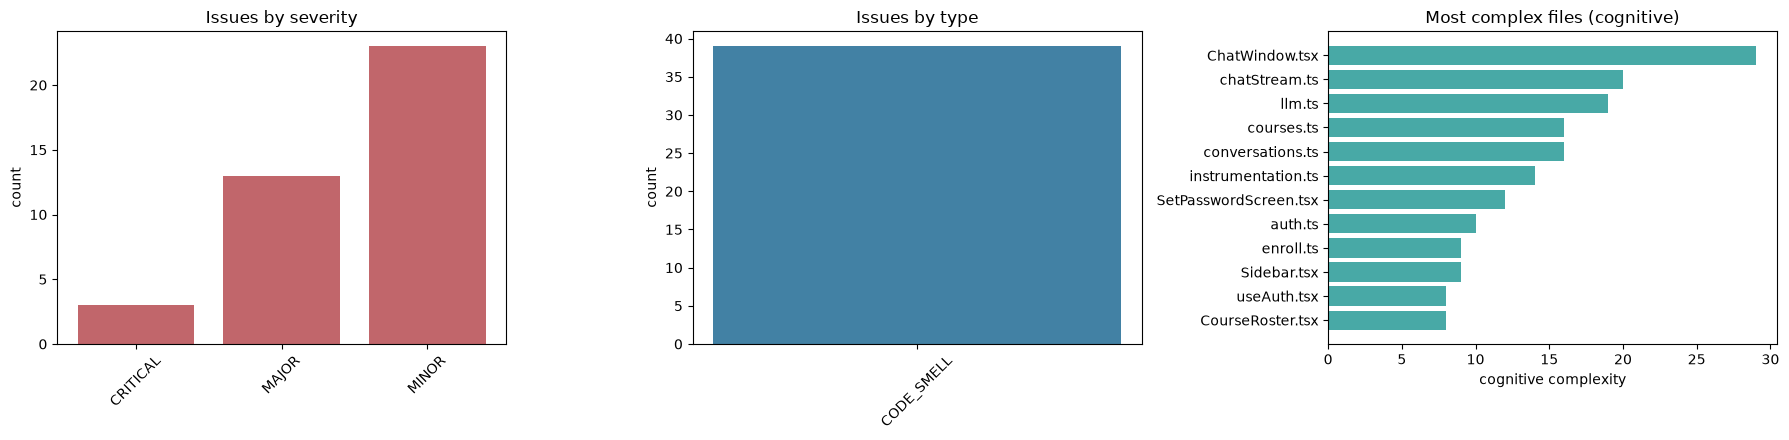

In [29]:
import matplotlib.pyplot as plt

have_issues = not issues_df.empty
have_files  = not files_df.empty

n = int(have_issues) * 2 + int(have_files)
if n == 0:
    print("Nothing to plot.")
else:
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.5))
    axes = list(axes) if n > 1 else [axes]
    i = 0

    if have_issues:
        s = issues_df.groupby("severity", observed=True).size()
        axes[i].bar(s.index.astype(str), s.values, color="#c1666b")
        axes[i].set_title("Issues by severity")
        axes[i].set_ylabel("count")
        axes[i].tick_params(axis="x", rotation=45)
        i += 1

        t = issues_df.groupby("type", observed=True).size()
        axes[i].bar(t.index.astype(str), t.values, color="#4281a4")
        axes[i].set_title("Issues by type")
        axes[i].set_ylabel("count")
        axes[i].tick_params(axis="x", rotation=45)
        i += 1

    if have_files:
        top = files_df.head(12).iloc[::-1]
        labels = [str(f).replace("\\", "/").split("/")[-1] for f in top["file"]]
        axes[i].barh(labels, top["cognitive_complexity"], color="#48a9a6")
        axes[i].set_title("Most complex files (cognitive)")
        axes[i].set_xlabel("cognitive complexity")

    plt.tight_layout()
    plt.show()

## 15. Open the dashboard

In [30]:
url = f"{SONAR_HOST}/dashboard?id={PROJECT_KEY}"
print(f"Dashboard: {url}")
print(f"Login: {SONAR_ADMIN} / {SONAR_NEW_PASSWORD}")

import webbrowser
webbrowser.open(url)

Dashboard: http://localhost:9000/dashboard?id=Aida-starter-template--r2-0901
Login: admin / Analysis!2024


True

## 16. Compare branches over time

Re-runs the clone/scan/measure pipeline for every branch in `REPO_BRANCHES`
(configured in cell 3), so the project-level metrics table from section 12 can
be seen evolving across snapshots instead of just for one branch.

Each branch gets its own SonarQube project key (`SEPARATE_PROJECT_PER_BRANCH`
must stay `True`), so re-running this is safe and just refreshes each project.
This takes roughly as long as sections 6-11 did, multiplied by
`len(REPO_BRANCHES)` - the scanner and lizard both run once per branch.

At the end, the working tree is checked back out to the single `REPO_BRANCH`
configured in cell 3, so re-running the sections above still analyzes the
branch you originally configured.

In [31]:
def checkout_branch(branch):
    """Fetch and hard-check-out `branch`. Mirrors cell 4's logic for REPO_BRANCH,
    factored out so it can run in a loop over REPO_BRANCHES."""
    git("config", "remote.origin.fetch", "+refs/heads/*:refs/remotes/origin/*")
    r = git("fetch", "origin", branch, "--quiet")
    if r.returncode != 0:
        raise RuntimeError(f"Could not fetch branch '{branch}':\n{r.stderr}")

    # never clobber uncommitted work (.scannerwork is untracked, so it is ignored here)
    dirty = git("status", "--porcelain", "--untracked-files=no").stdout.strip()
    if dirty:
        raise RuntimeError(
            f"{REPO_DIR} has uncommitted changes - refusing to switch branches.\n{dirty}"
        )

    r = git("checkout", "-B", branch, f"origin/{branch}", "--quiet")
    if r.returncode != 0:
        raise RuntimeError(f"Could not check out '{branch}':\n{r.stderr}")

    return git("log", "-1", "--format=%h %ad %s", "--date=short").stdout.strip()


def project_key_for(branch):
    base = f"{REPO_NAME}--{branch}" if SEPARATE_PROJECT_PER_BRANCH else REPO_NAME
    return re.sub(r"[^A-Za-z0-9_.\-]", "-", base)


def ensure_project(project_key, project_name):
    r = _api("POST", "/api/projects/create", auth,
             data={"project": project_key, "name": project_name})
    if r.status_code not in (200, 204, 400):
        raise RuntimeError(f"Unexpected response {r.status_code}: {r.text}")


def run_scan(project_key, project_name):
    """Same scanner invocation as section 8, but blocking and quiet - a progress
    stream per branch is more noise than signal here."""
    scan_env = dict(os.environ, SONAR_SCANNER_OPTS=SCANNER_OPTS)
    cmd = [
        str(SCANNER_BIN),
        f"-Dsonar.projectKey={project_key}",
        f"-Dsonar.projectName={project_name}",
        "-Dsonar.sources=.",
        f"-Dsonar.projectBaseDir={REPO_DIR}",
        f"-Dsonar.host.url={SONAR_HOST}",
        f"-Dsonar.token={SONAR_TOKEN}",
        f"-Dsonar.exclusions={EXCLUSIONS}",
        "-Dsonar.sourceEncoding=UTF-8",
        "-Dsonar.scm.disabled=true",
    ]
    proc = subprocess.run(cmd, cwd=str(REPO_DIR), env=scan_env,
                          capture_output=True, text=True, encoding="utf-8", errors="replace")
    if proc.returncode != 0:
        raise RuntimeError(f"sonar-scanner exited with code {proc.returncode}:\n"
                           + "\n".join(proc.stdout.splitlines()[-40:]))

    # same background-task wait as section 9
    task_file = REPO_DIR / ".scannerwork" / "report-task.txt"
    meta = dict(l.split("=", 1) for l in task_file.read_text().strip().splitlines() if "=" in l)
    task_id = meta["ceTaskId"]

    deadline = time.time() + 300
    task_status = None
    while time.time() < deadline:
        task = _api("GET", "/api/ce/task", auth, params={"id": task_id}).json().get("task", {})
        task_status = task.get("status")
        if task_status in ("SUCCESS", "FAILED", "CANCELED"):
            break
        time.sleep(3)
    if task_status != "SUCCESS":
        raise RuntimeError(f"Report processing did not succeed (status={task_status}) for {project_key}")


def fetch_measures(project_key):
    r = _api("GET", "/api/measures/component", auth,
             params={"component": project_key, "metricKeys": ",".join(METRICS)})
    r.raise_for_status()
    return {m["metric"]: m.get("value")
            for m in r.json().get("component", {}).get("measures", [])}

In [32]:
raw_measures_by_branch = {}
branch_rows = []

for branch in REPO_BRANCHES:
    print(f"\n=== {branch} ===")
    try:
        head = checkout_branch(branch)
    except RuntimeError as exc:
        print(f"  skip: {exc}")
        continue
    print(f"  HEAD: {head}")

    project_key  = project_key_for(branch)
    project_name = f"{REPO_NAME}--{branch}" if SEPARATE_PROJECT_PER_BRANCH else REPO_NAME
    ensure_project(project_key, project_name)

    print("  scanning ...")
    run_scan(project_key, project_name)

    measures = fetch_measures(project_key)
    raw_measures_by_branch[branch] = measures

    row = {"branch": branch, "head": head}
    for m in METRICS:
        row[m] = pd.to_numeric(measures.get(m), errors="coerce")

    fn_df = analyze_functions(REPO_DIR)
    row.update(lizard_summary(fn_df))
    branch_rows.append(row)

# restore the working tree to the single branch the rest of the notebook expects
if REPO_BRANCH:
    try:
        checkout_branch(REPO_BRANCH)
    except RuntimeError as exc:
        print(f"\nCould not restore '{REPO_BRANCH}': {exc}")

branch_df = pd.DataFrame(branch_rows).set_index("branch")
branch_df = branch_df.reindex([b for b in REPO_BRANCHES if b in branch_df.index])
print()
print(f"Compared {len(branch_df)}/{len(REPO_BRANCHES)} branches.")


=== main ===
  HEAD: 7f2cad8 2026-08-31 Add Claude Code guardrails: plan mode + UI test block
  scanning ...

=== r1-0901 ===
  HEAD: ce31a3a 2026-09-01 completed: round 1 (Sep 1st)
  scanning ...

=== r2-0901 ===
  HEAD: c8858ff 2026-09-01 completed: round 2 (Sep 1st)
  scanning ...

=== r3-0901 ===
  HEAD: 03d8d7e 2026-09-03 complete: round 3
  scanning ...

=== r4-0901 ===
  HEAD: b05cfb3 2026-09-04 completed: r4
  scanning ...

Compared 5/5 branches.


In [33]:
# Same metric -> display-string formatting as section 12's pretty(), just laid
# out with one column per branch instead of one row per metric.
pretty_table = pd.DataFrame({
    branch: {m: pretty(m, raw_measures_by_branch[branch].get(m)) for m in METRICS}
    for branch in branch_df.index
})
pretty_table.index.name = "metric"

lz_keys = [k for k in branch_df.columns if k.startswith("lz_")]
if lz_keys:
    lz_table = branch_df[lz_keys].T
    lz_table.index.name = "metric"
    pretty_table = pd.concat([pretty_table, lz_table])

display(pretty_table)

,main,r1-0901,r2-0901,r3-0901,r4-0901
metric,,,,,
ncloc,658,1605,2760,4677,5863
files,14,36,50,73,84
functions,19,136,229,400,493
classes,0,1,2,2,4
statements,81,555,924,1521,2010
comment_lines_density,2.5%,3.4%,3.8%,4.3%,5.3%
complexity,41,270,457,806,1064
cognitive_complexity,14,140,231,413,612
bugs,0,0,0,4,7


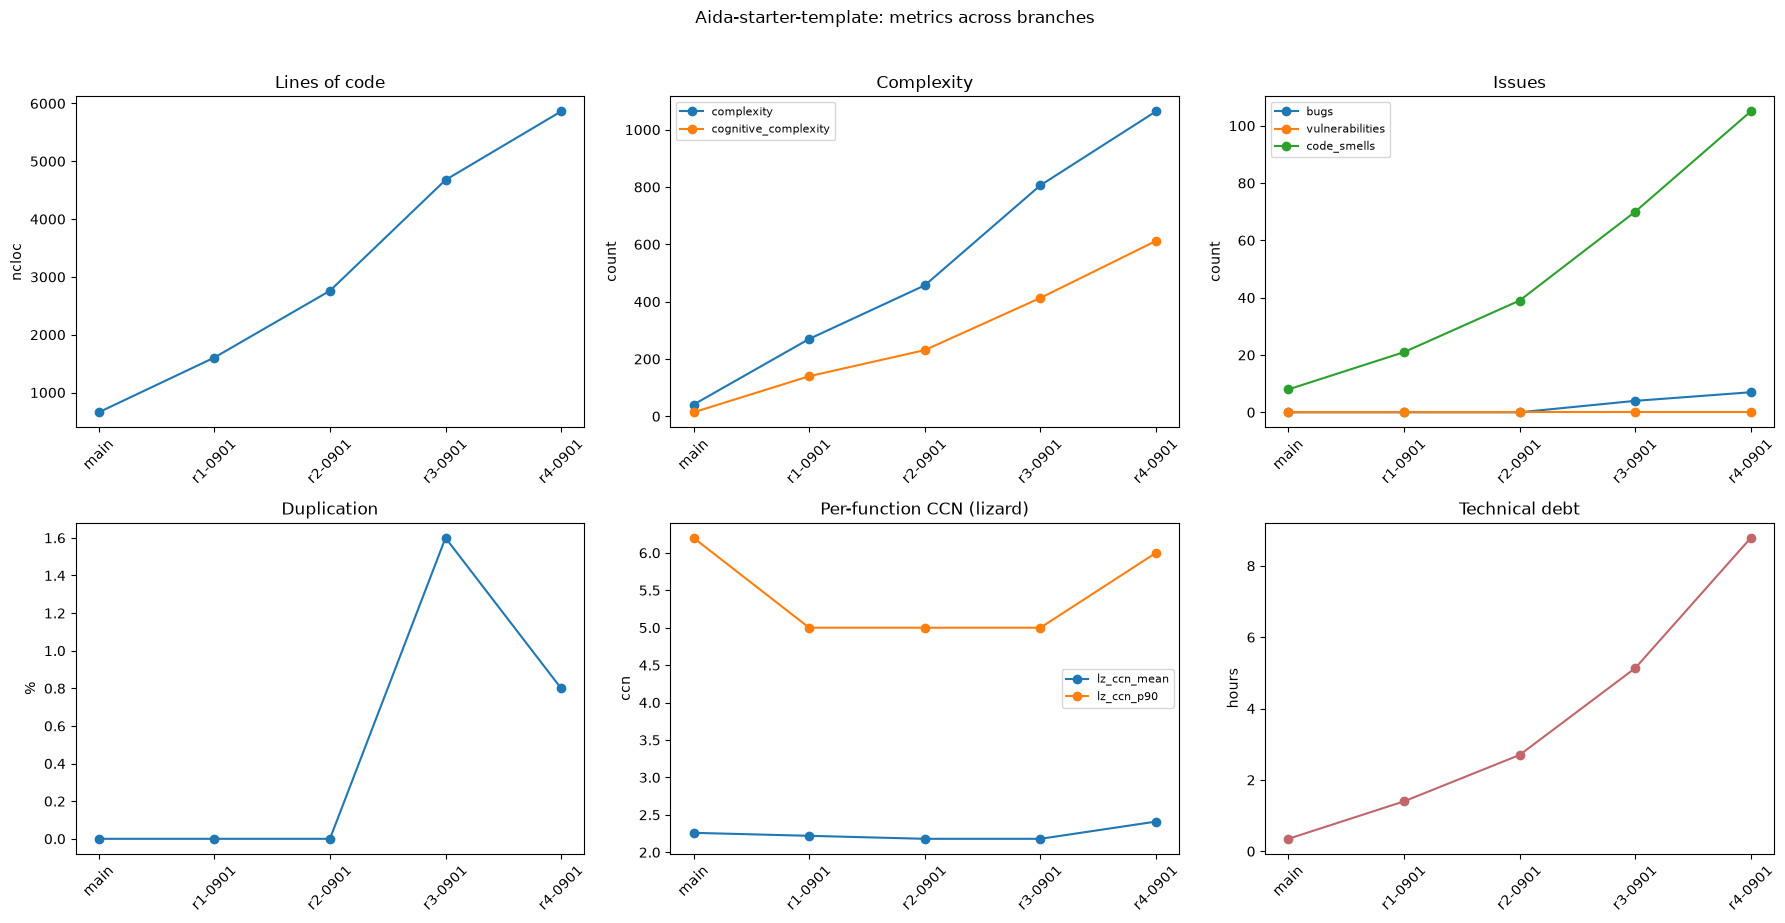

In [34]:
import matplotlib.pyplot as plt

if branch_df.empty:
    print("Nothing to plot.")
else:
    x = branch_df.index.astype(str)

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.ravel()

    def line(ax, cols, title, ylabel):
        for col in cols:
            if col in branch_df:
                ax.plot(x, branch_df[col], marker="o", label=col)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=45)
        if len(cols) > 1:
            ax.legend(fontsize=8)

    line(axes[0], ["ncloc"], "Lines of code", "ncloc")
    line(axes[1], ["complexity", "cognitive_complexity"], "Complexity", "count")
    line(axes[2], ["bugs", "vulnerabilities", "code_smells"], "Issues", "count")
    line(axes[3], ["duplicated_lines_density"], "Duplication", "%")
    line(axes[4], ["lz_ccn_mean", "lz_ccn_p90"], "Per-function CCN (lizard)", "ccn")

    if "sqale_index" in branch_df:
        axes[5].plot(x, branch_df["sqale_index"] / 60, marker="o", color="#c1666b")
        axes[5].set_title("Technical debt")
        axes[5].set_ylabel("hours")
        axes[5].tick_params(axis="x", rotation=45)
    else:
        axes[5].axis("off")

    fig.suptitle(f"{REPO_NAME}: metrics across branches", y=1.02)
    fig.tight_layout()
    plt.show()

### Bugs & code smells for one branch

Looks up open issues for a single already-scanned branch, without re-running the
scan. Works for the configured `REPO_BRANCH`, any branch from `REPO_BRANCHES`
(section 16), or anything else you've scanned - it just queries the branch's
existing SonarQube project.

In [35]:
check_branch = "r4-0901"   # any branch that has already been scanned


In [37]:
_check_key = project_key_for(check_branch) if SEPARATE_PROJECT_PER_BRANCH else PROJECT_KEY
raw = fetch_issues(_check_key)

if not raw:
    print(f"No open issues returned for project '{_check_key}'.")
    print("Either the branch is clean, or it hasn't been scanned yet - check it out "
          "and scan it (sections 3 + 8, or the branch-comparison loop in section 16) first.")
    check_df = pd.DataFrame()
else:
    rows = []
    for issue in raw:
        # SonarQube 10+ reports "impacts"; older versions only "severity"/"type"
        impacts = issue.get("impacts") or []
        rows.append({
            "severity": issue.get("severity") or (impacts[0]["severity"] if impacts else None),
            "type":     issue.get("type") or (impacts[0]["softwareQuality"] if impacts else None),
            "file":     issue.get("component", "").split(":", 1)[-1],
            "line":     issue.get("textRange", {}).get("startLine"),
            "rule":     issue.get("rule"),
            "effort":   issue.get("effort"),
            "message":  issue.get("message"),
        })
    check_df = pd.DataFrame(rows)
    check_df["line"] = pd.to_numeric(check_df["line"], errors="coerce").astype("Int64")

    sev_order = ["BLOCKER", "CRITICAL", "HIGH", "MAJOR", "MEDIUM", "MINOR", "LOW", "INFO"]
    present = [s for s in sev_order if s in set(check_df["severity"])]
    check_df["severity"] = pd.Categorical(check_df["severity"], categories=present, ordered=True)
    check_df = check_df.sort_values(["severity", "file", "line"]).reset_index(drop=True)

    print(f"{_check_key}: {len(check_df)} open issues\n")
    print("=== By severity ===")
    display(check_df.groupby("severity", observed=True).size().rename("count").reset_index())
    print("=== By type ===")
    display(check_df.groupby("type", observed=True).size().rename("count").reset_index())

    pd.set_option("display.max_colwidth", None)  # None = show full message text, no "..."
    pd.set_option("display.max_rows", 200)
    print("=== All open issues ===")
    display(check_df)

Aida-starter-template--r4-0901: 112 open issues

=== By severity ===


,severity,count
0,CRITICAL,7
1,MAJOR,50
2,MINOR,54
3,INFO,1


=== By type ===


,type,count
0,BUG,7
1,CODE_SMELL,105


=== All open issues ===


,severity,type,file,line,rule,effort,message
0,CRITICAL,CODE_SMELL,apps/web/src/App.tsx,76,typescript:S3735,5min,"Remove this use of the ""void"" operator."
1,CRITICAL,CODE_SMELL,apps/web/src/components/InstructorApp.tsx,28,typescript:S3735,5min,"Remove this use of the ""void"" operator."
2,CRITICAL,CODE_SMELL,apps/web/src/components/MaterialsManager.tsx,24,typescript:S3735,5min,"Remove this use of the ""void"" operator."
3,CRITICAL,CODE_SMELL,apps/web/src/components/MaterialsManager.tsx,107,typescript:S3735,5min,"Remove this use of the ""void"" operator."
4,CRITICAL,CODE_SMELL,services/code-trace/main.py,105,python:S3776,8min,Refactor this function to reduce its Cognitive Complexity from 18 to the 15 allowed.
5,CRITICAL,CODE_SMELL,services/code-trace/main.py,147,python:S3776,33min,Refactor this function to reduce its Cognitive Complexity from 43 to the 15 allowed.
6,CRITICAL,CODE_SMELL,services/code-trace/main.py,225,python:S3776,30min,Refactor this function to reduce its Cognitive Complexity from 40 to the 15 allowed.
7,MAJOR,CODE_SMELL,apps/api/src/prompt.ts,51,typescript:S4624,10min,Refactor this code to not use nested template literals.
8,MAJOR,CODE_SMELL,apps/api/src/routes/conversations.ts,68,typescript:S4043,5min,"Move this array ""reverse"" operation to a separate statement or replace it with ""toReversed""."
9,MAJOR,CODE_SMELL,apps/api/src/routes/conversations.ts,246,typescript:S6582,5min,"Prefer using an optional chain expression instead, as it's more concise and easier to read."


---
### Analyzing another repository

Change `REPO_URL` in the config cell and re-run from cell 1. Each repo gets its own
project key, so results do not overwrite each other.

### Cleanup

```
docker stop sonarqube      # pause the server; `docker start sonarqube` resumes it
docker rm -f sonarqube     # remove it entirely (deletes all analysis history)
```